# 02 — Anomaly Detection (ROAD)

The pipeline runs across all throughput limitations in `THROUGHPUT_LIMS`.
Each section is a separate cell — you can re-run any phase independently
without restarting from scratch.

| Section | Description |
|---|---|
| 0 | Imports & configuration |
| 1 | Load data |
| 2 | Filter & prepare per limitation |
| 3 | Detector benchmark |
| 4 | Normality model + anomaly detection |
| 5 | Explainability (SHAP) |
| 6 | SAFE AI metrics (RGA / RGE / RGR) |
| 7 | ROAD feature ranking |
| 8 | Decision tree |

**Input:** `data/aggregated_stats.csv`  
**Outputs:** `decision_trees/lim_*.png`

## 0. Imports & configuration

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn import tree
import graphviz

from src.config import (
    DATA_PATH, TREE_DIR,
    TARGET, THROUGHPUT_LIMS,
    DT_MAX_DEPTH, DT_MIN_SAMPLES, DT_CROSS_VAL,
)
from src.preprocessing_functions import norm_cols
from src.detection import mad_outliers, benchmark_detectors, score_table
from src.explainability import (
    prepare_training_split,
    fit_normality_model,
    predict_target,
    compute_residuals,
    detect_residual_anomalies,
    compute_shap_values,
    rank_features_by_mean_abs_shap,
)
from src.tree_utils import DTClassifier
from src.road import cluster_anomaly_support_optimal
from src.safeai import safeai_summary
from src.plot_functions import (
    plot_shap_summary,
    plot_xgb_importance,
    plot_road_ranking,
    plot_prediction_diagnostics,
)

TREE_DIR.mkdir(parents=True, exist_ok=True)

# shared state across cells — populated incrementally
results = {lim: {} for lim in THROUGHPUT_LIMS}
print(f"Initialised results for {len(THROUGHPUT_LIMS)} limitations: {THROUGHPUT_LIMS}")

Initialised results for 6 limitations: ['1000kbit', '2000kbit', '5000kbit', '10000kbit', '20000kbit', '50000kbit']


## 1. Load data

In [5]:
data_raw = norm_cols(
    pd.read_csv(DATA_PATH, encoding="ISO-8859-1", low_memory=False)
)
print(f"Loaded: {data_raw.shape[0]} rows, {data_raw.shape[1]} columns")
data_raw.head()

Loaded: 7220 rows, 537 columns


,uuid,filename,test,limitation,throughputlim,latencylim,packetlosslim,interface,counts,dl.throughput.value,...,rcvooopack.q90,sndwnd.min,sndwnd.max,sndwnd.mean,sndwnd.std,sndwnd.median,sndwnd.q10,sndwnd.q25,sndwnd.q75,sndwnd.q90
0,02ba0c6280d1_1762202749_00000000000025D4,WIFI_2025-11-10_02-00-11_UTC.txt,DL,NaN,NaN,NaN,NaN,wlp0s20f3,30,593.277440,...,0.0,1529728,1597440,1.563708e+06,18088.656058,1559296.0,1539225.6,1550144.0,1577984.0,1585395.2
1,b60f1e0a02e1_1762202749_00000000000002F0,WIFI_2025-11-07_20-11-10_UTC.txt,DL,NaN,NaN,NaN,NaN,wlp0s20f3,30,579.654536,...,0.0,1407232,1592064,1.553621e+06,38550.646416,1557248.0,1543091.2,1549952.0,1577984.0,1583846.4
2,4bf7dc088d31_1762202749_00000000000004FD,WIFI_2025-11-11_16-24-57_UTC.txt,DL,Throughput,20000kbit,NaN,NaN,wlp0s20f3,22,18.040134,...,0.0,65152,413952,3.631244e+05,78861.850698,413952.0,328576.0,328576.0,413952.0,413952.0
3,02ba0c6280d1_1762202749_000000000000040B,WIFI_2025-11-10_07-53-54_UTC.txt,DL,NaN,NaN,NaN,NaN,wlp0s20f3,38,584.629354,...,0.0,1527680,1597440,1.568141e+06,17803.974398,1566848.0,1548953.6,1557248.0,1580576.0,1596160.0
4,16ed801fb1e7_1762202749_00000000000019B9,WIFI_2025-11-15_09-17-48_UTC.txt,DL,Latency,NaN,500ms,NaN,wlp0s20f3,11,7.570025,...,0.0,41984,1592832,5.049949e+05,551237.456553,269184.0,51712.0,68992.0,839488.0,1264512.0


## 2. Filter & prepare

For each limitation, select the relevant rows, apply log-transform to the KPI,
and compute the MAD outlier mask and contamination rate.

In [6]:
for lim in THROUGHPUT_LIMS:
    lim_mask      = data_raw["limitation"].isna() | (data_raw["throughputlim"] == lim)
    data_lim      = data_raw.loc[lim_mask].copy()
    outliers_real = (data_lim["throughputlim"] == lim).astype(int)

    pos_mask      = data_lim[TARGET] > 0
    data_lim      = data_lim.loc[pos_mask].copy()
    outliers_real = outliers_real.loc[data_lim.index]

    X_lim         = data_lim.select_dtypes(include="number").copy()
    X_lim[TARGET] = np.log10(X_lim[TARGET])

    outliers_mad  = mad_outliers(X_lim[TARGET])
    contamination = float(outliers_real.mean())

    results[lim].update({
        "X_lim":         X_lim,
        "outliers_real": outliers_real,
        "outliers_mad":  outliers_mad,
        "contamination": contamination,
    })

    print(f"{lim:12s} — samples: {len(X_lim):4d} | contamination: {contamination:.3f} | MAD outliers: {outliers_mad.sum()}")

1000kbit     — samples: 4446 | contamination: 0.048 | MAD outliers: 388
2000kbit     — samples: 4443 | contamination: 0.047 | MAD outliers: 386
5000kbit     — samples: 4444 | contamination: 0.048 | MAD outliers: 387
10000kbit    — samples: 4448 | contamination: 0.049 | MAD outliers: 390
20000kbit    — samples: 4450 | contamination: 0.049 | MAD outliers: 392
50000kbit    — samples: 4450 | contamination: 0.049 | MAD outliers: 392


## 3. Detector benchmark

Fit 12 PyOD detectors and MAD against the ground-truth outlier labels.
Results are sorted by F1-score.

In [7]:
for lim in THROUGHPUT_LIMS:
    r   = results[lim]
    X   = r["X_lim"]
    y   = r["outliers_real"]
    mad = r["outliers_mad"]

    comparison = benchmark_detectors(X, y, r["contamination"])
    mad_row    = {"method": "MAD", **score_table(y, mad.astype(int))}
    comparison = pd.concat(
        [comparison, pd.DataFrame([mad_row])], ignore_index=True
    ).sort_values("f1_score", ascending=False)

    results[lim]["comparison"] = comparison

    print(f"\n=== {lim} ===")
    print(comparison.to_string(index=False))
    print("-" * 65)


=== 1000kbit ===
 method  sensitivity  specificity  f1_score  precision  jaccard
  COPOD     1.000000     1.000000  1.000000   1.000000 1.000000
   ECOD     1.000000     1.000000  1.000000   1.000000 1.000000
   LODA     1.000000     1.000000  1.000000   1.000000 1.000000
IForest     0.995327     0.999764  0.995327   0.995327 0.990698
  CBLOF     0.990654     0.999527  0.990654   0.990654 0.981481
    PCA     0.957944     0.997873  0.957944   0.957944 0.919283
   HBOS     0.929907     0.996456  0.929907   0.929907 0.868996
    MAD     1.000000     0.958885  0.710963   0.551546 0.551546
    GMM     0.514019     0.975425  0.514019   0.514019 0.345912
    COF     0.359813     0.967628  0.359813   0.359813 0.219373
    LOF     0.168224     0.961484  0.174334   0.180905 0.095491
    KNN     0.023364     0.957940  0.025189   0.027322 0.012755
    KDE     0.000000     1.000000  0.000000   0.000000 0.000000
-----------------------------------------------------------------

=== 2000kbit ===
 m

## 4. Normality model + anomaly detection

Train XGBoost on non-outlier samples, compute residuals, detect anomalies
via OneClassSVM on the residual distribution.

In [8]:
for lim in THROUGHPUT_LIMS:
    r   = results[lim]
    X   = r["X_lim"]
    mad = r["outliers_mad"]

    X_train, y_train, X_all = prepare_training_split(X, mad, target=TARGET)

    model       = fit_normality_model(X_train, y_train)
    y_predicted = predict_target(model, X_all)
    residuals   = compute_residuals(X.loc[X_all.index, TARGET], y_predicted)
    anomalies   = pd.Series(detect_residual_anomalies(residuals), index=X_all.index)

    results[lim].update({
        "X_train":    X_train,
        "y_train":    y_train,
        "X_all":      X_all,
        "model":      model,
        "y_predicted": y_predicted,
        "residuals":  residuals,
        "anomalies":  anomalies,
    })

    print(f"{lim:12s} — anomalies: {anomalies.sum():3d} / {len(anomalies)}")

1000kbit     — anomalies: 4232 / 4446
2000kbit     — anomalies: 4232 / 4443
5000kbit     — anomalies: 4232 / 4444
10000kbit    — anomalies: 4232 / 4448
20000kbit    — anomalies: 4232 / 4450
50000kbit    — anomalies: 4232 / 4450


## 5. Explainability — SHAP

SHAP values quantify the marginal contribution of each feature to individual predictions.
The beeswarm plot shows both direction and magnitude of each feature's impact.


=== 1000kbit — top 10 features by mean |SHAP| ===
                feature  mean_abs_shap
         bytesacked.max       0.005519
          delivered.max       0.002958
             minrtt.std       0.000517
            segsout.max       0.000497
        elapsedtime.max       0.000308
        datasegsout.max       0.000307
           busytime.max       0.000163
          bytessent.max       0.000095
             minrtt.q90       0.000074
dl.retransmission.value       0.000045


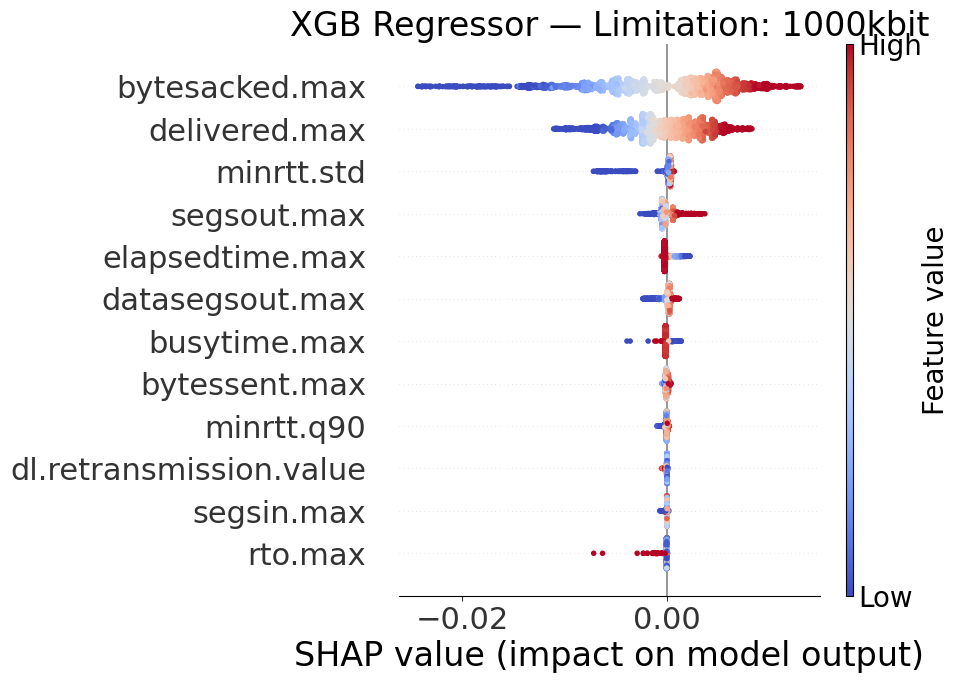

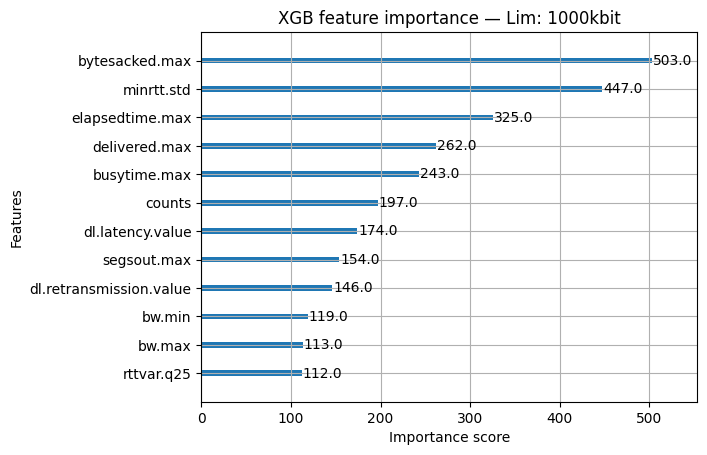

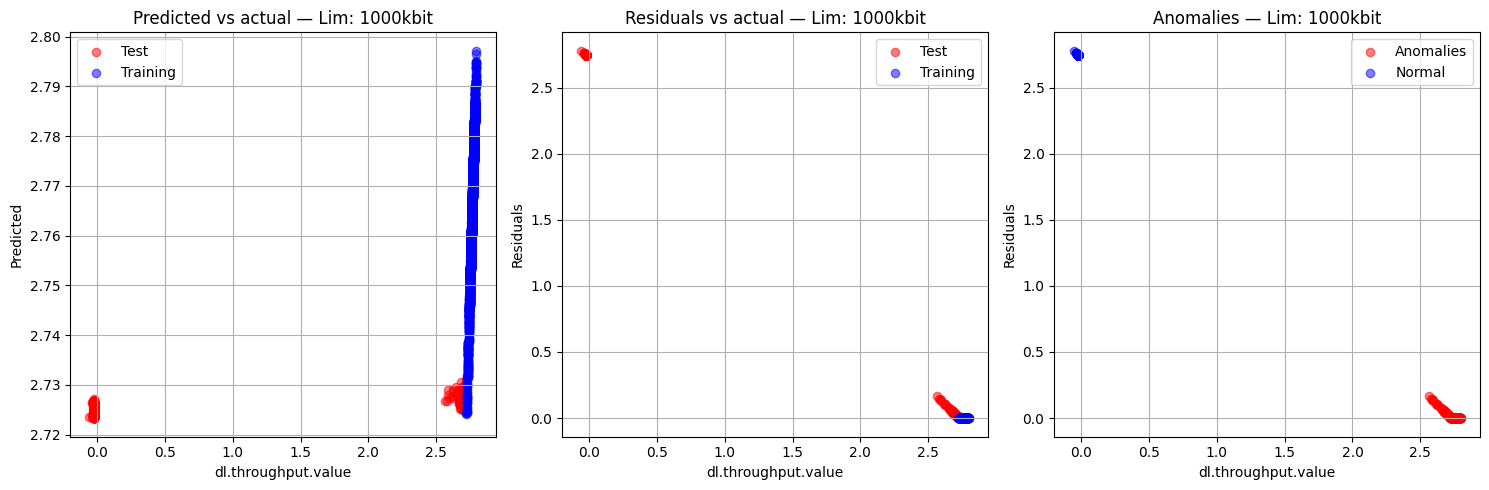


=== 2000kbit — top 10 features by mean |SHAP| ===
         feature  mean_abs_shap
  bytesacked.max       0.004784
   delivered.max       0.003601
      minrtt.std       0.000518
     segsout.max       0.000393
 elapsedtime.max       0.000325
 datasegsout.max       0.000290
    busytime.max       0.000146
   bytessent.max       0.000094
      minrtt.q90       0.000081
totalretrans.max       0.000075


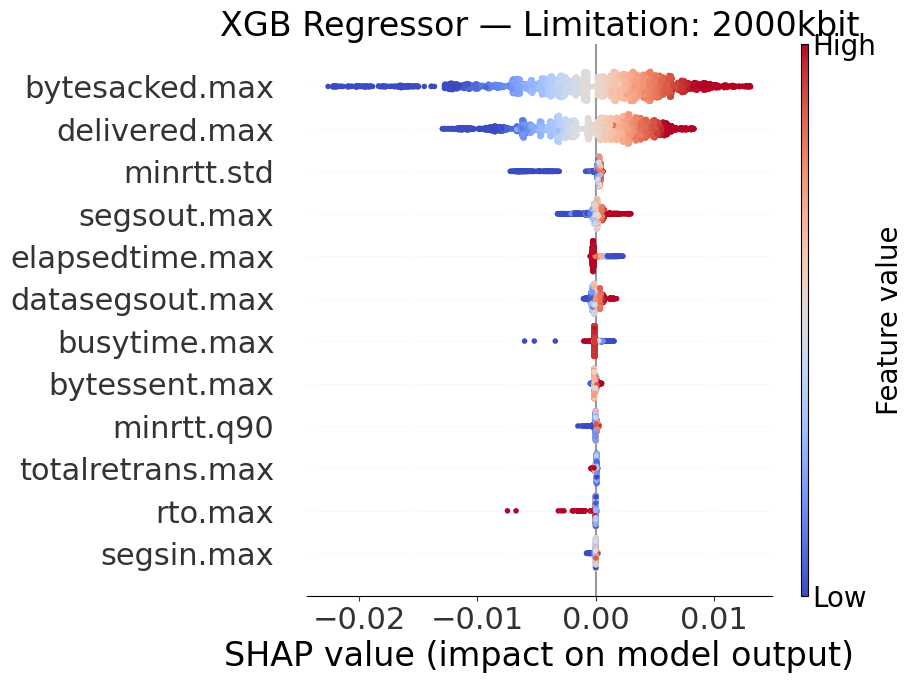

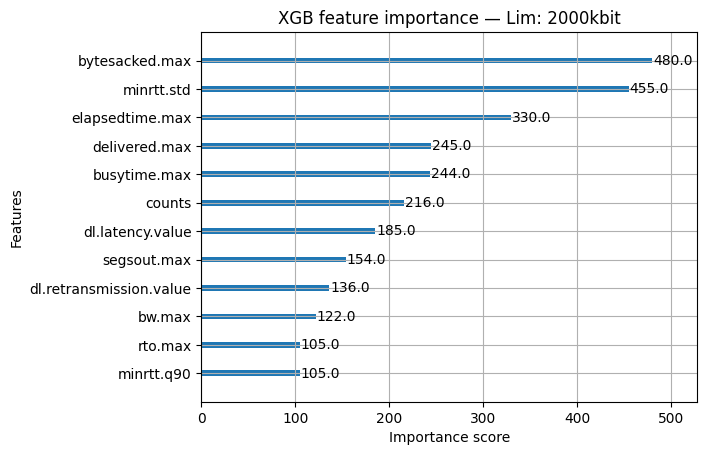

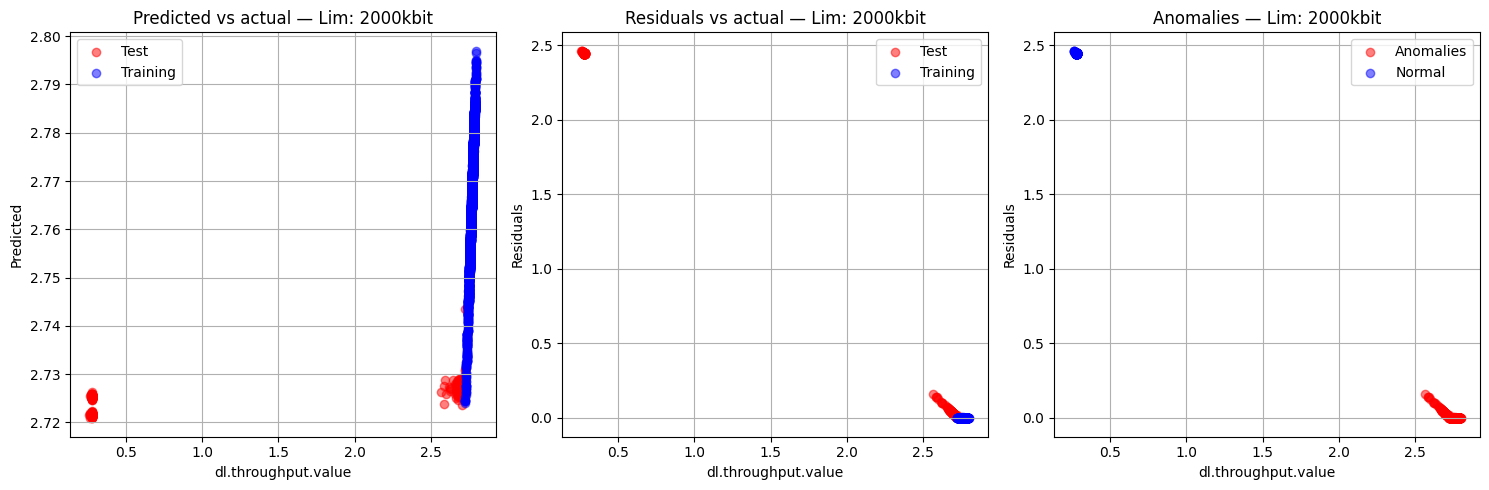


=== 5000kbit — top 10 features by mean |SHAP| ===
         feature  mean_abs_shap
  bytesacked.max       0.004784
   delivered.max       0.003601
      minrtt.std       0.000518
     segsout.max       0.000393
 elapsedtime.max       0.000325
 datasegsout.max       0.000290
    busytime.max       0.000146
   bytessent.max       0.000094
      minrtt.q90       0.000081
totalretrans.max       0.000075


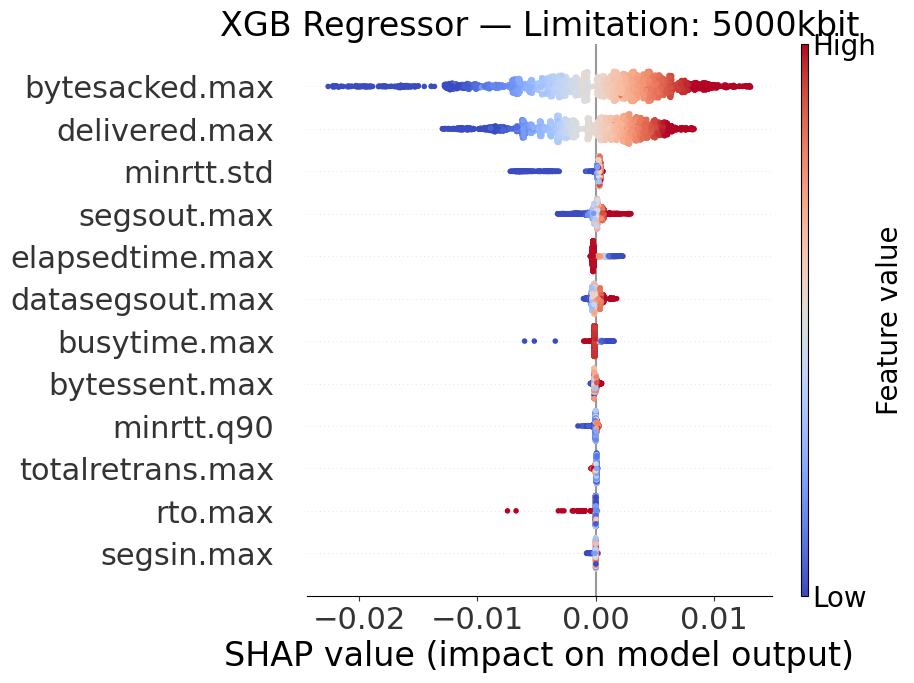

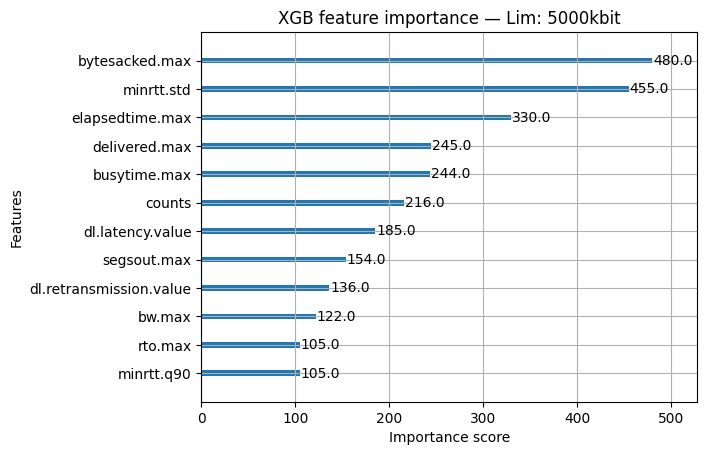

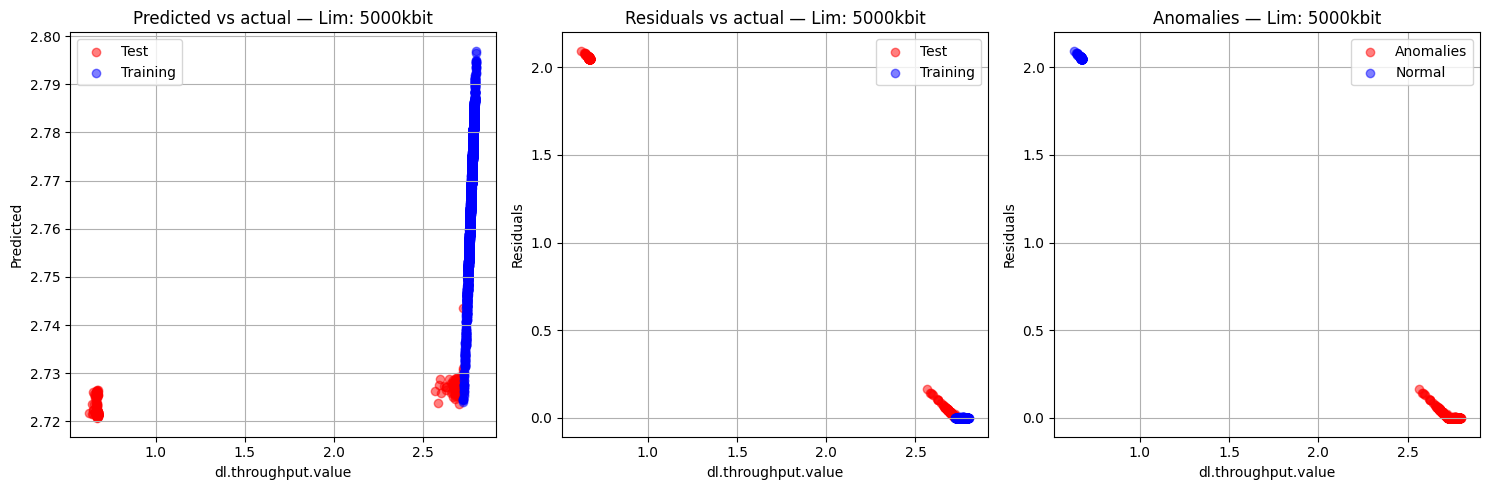


=== 10000kbit — top 10 features by mean |SHAP| ===
                feature  mean_abs_shap
         bytesacked.max       0.005519
          delivered.max       0.002958
             minrtt.std       0.000517
            segsout.max       0.000497
        elapsedtime.max       0.000308
        datasegsout.max       0.000307
           busytime.max       0.000163
          bytessent.max       0.000095
             minrtt.q90       0.000074
dl.retransmission.value       0.000045


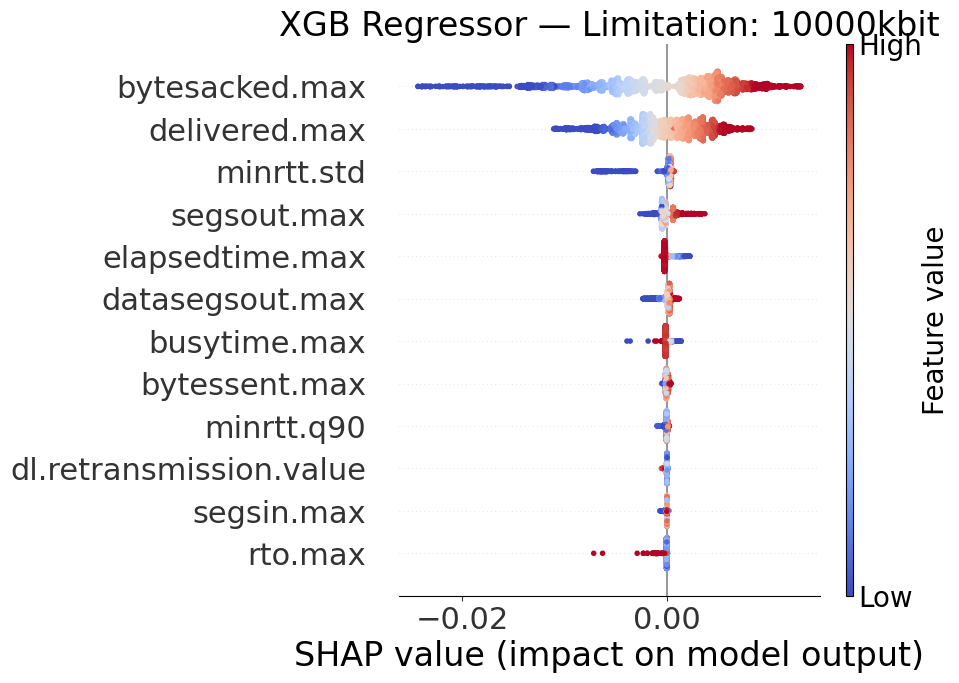

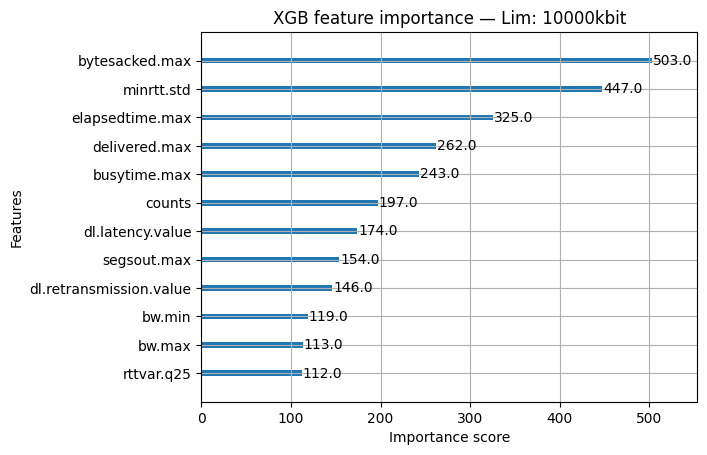

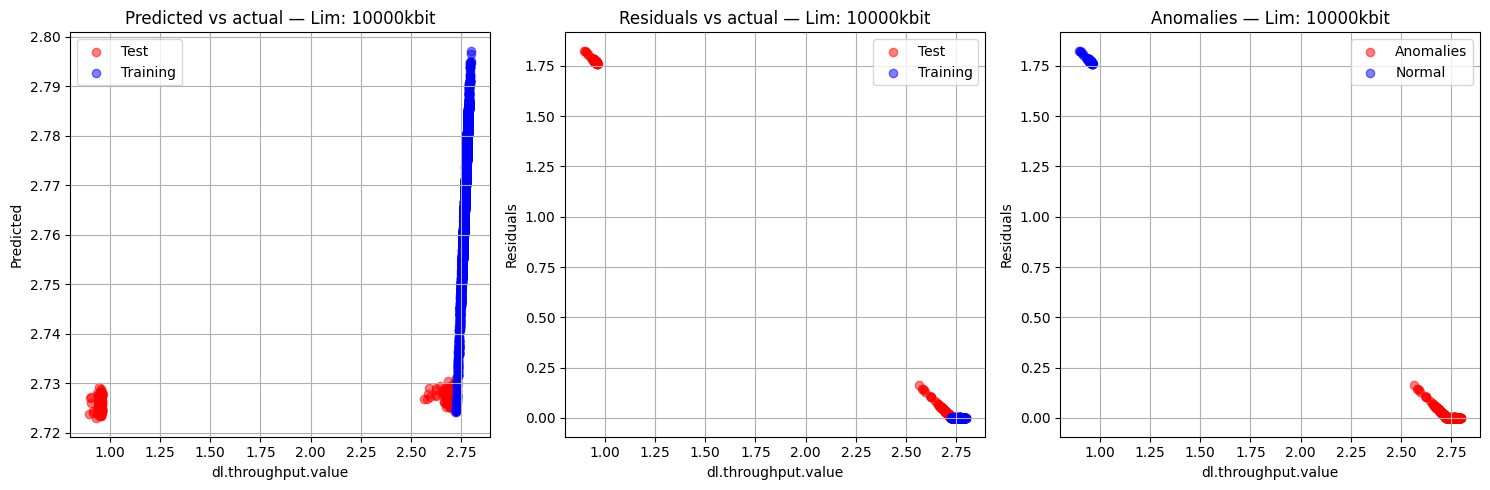


=== 20000kbit — top 10 features by mean |SHAP| ===
                feature  mean_abs_shap
         bytesacked.max       0.005519
          delivered.max       0.002958
             minrtt.std       0.000517
            segsout.max       0.000497
        elapsedtime.max       0.000308
        datasegsout.max       0.000307
           busytime.max       0.000163
          bytessent.max       0.000095
             minrtt.q90       0.000074
dl.retransmission.value       0.000045


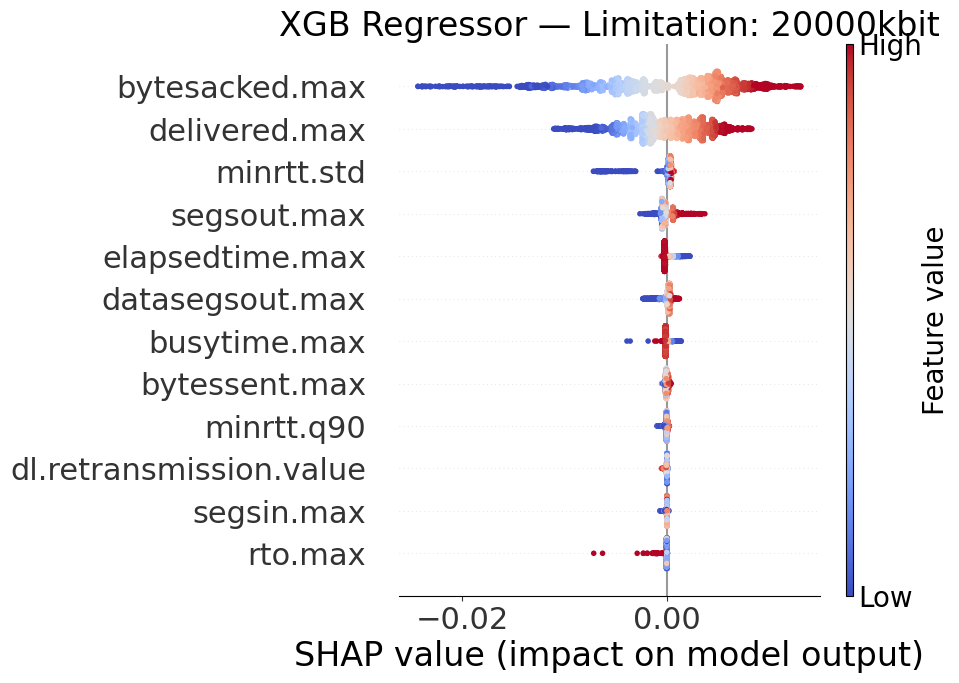

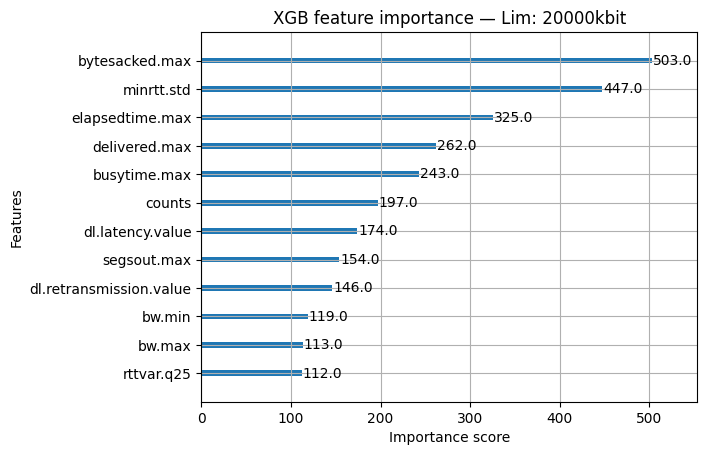

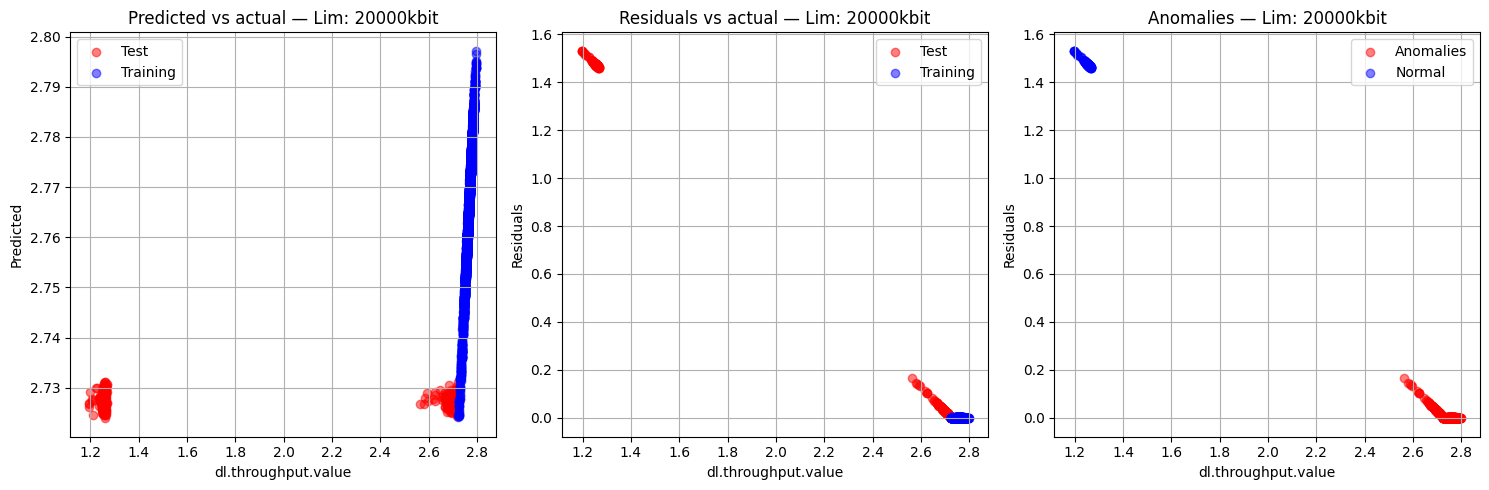


=== 50000kbit — top 10 features by mean |SHAP| ===
                feature  mean_abs_shap
         bytesacked.max       0.005519
          delivered.max       0.002958
             minrtt.std       0.000517
            segsout.max       0.000497
        elapsedtime.max       0.000308
        datasegsout.max       0.000307
           busytime.max       0.000163
          bytessent.max       0.000095
             minrtt.q90       0.000074
dl.retransmission.value       0.000045


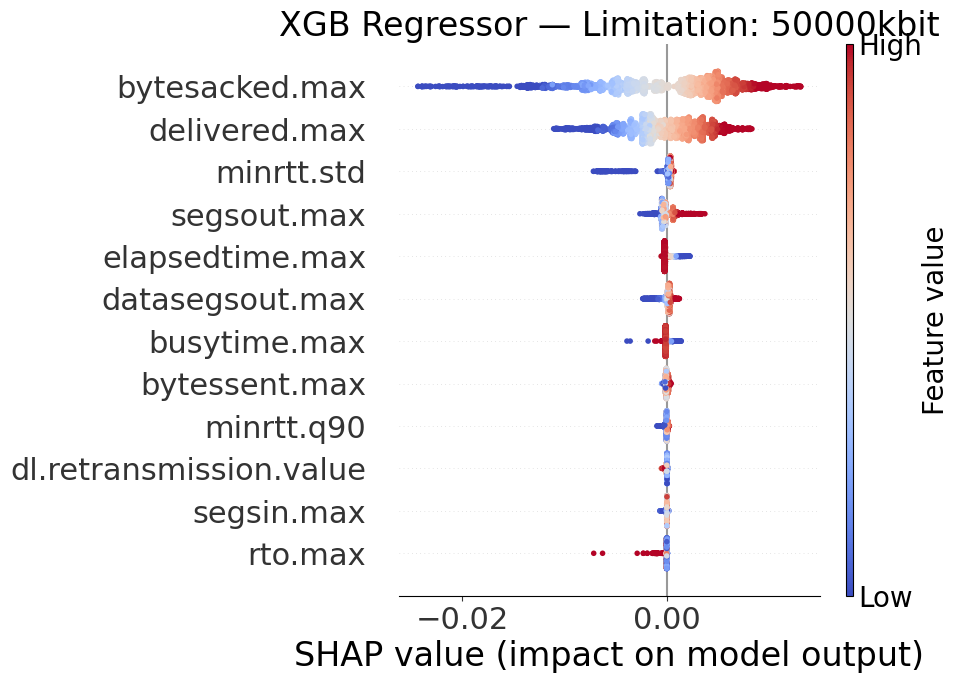

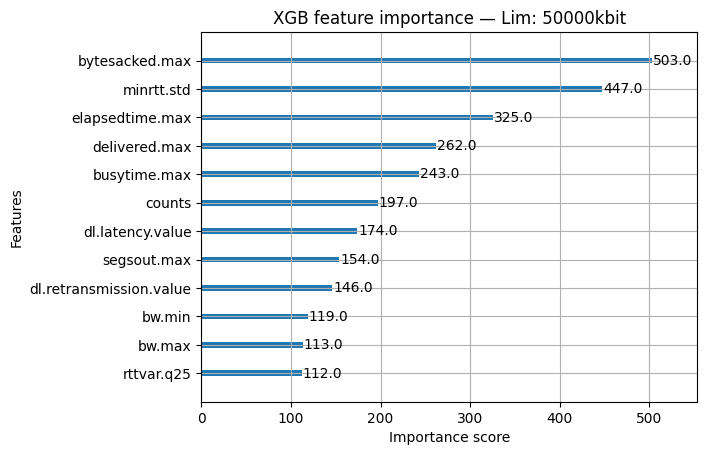

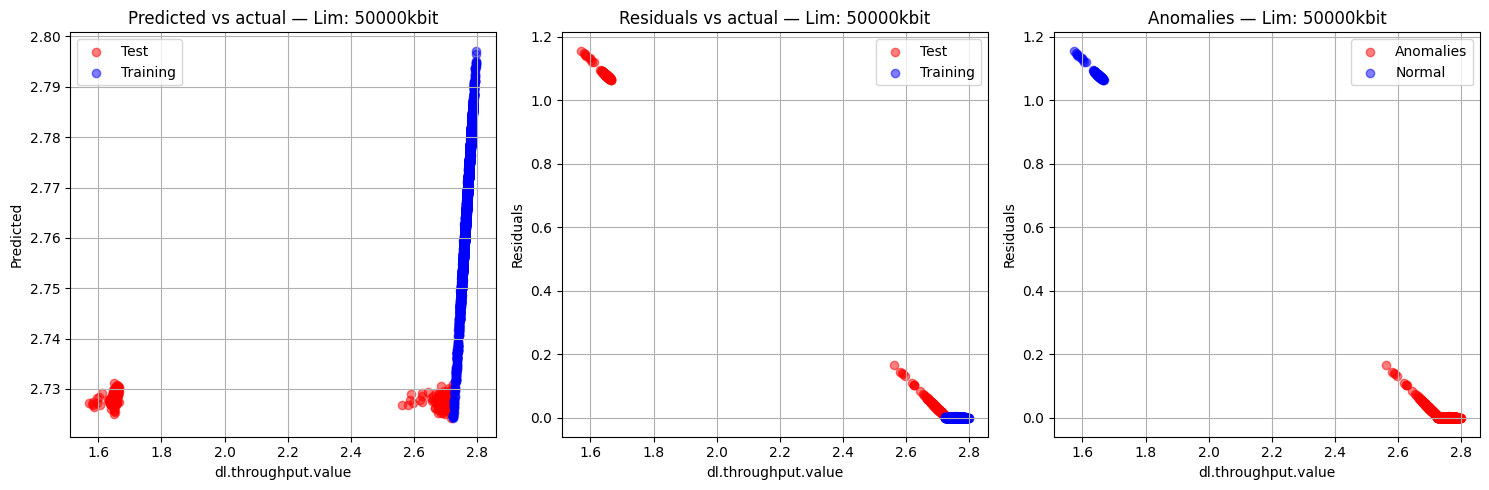

In [9]:
for lim in THROUGHPUT_LIMS:
    r = results[lim]

    shap_values  = compute_shap_values(r["model"], r["X_train"])
    shap_ranking = rank_features_by_mean_abs_shap(shap_values, r["X_train"].columns)

    results[lim].update({
        "shap_values":  shap_values,
        "shap_ranking": shap_ranking,
    })

    print(f"\n=== {lim} — top 10 features by mean |SHAP| ===")
    print(shap_ranking.head(10).to_string(index=False))

    plot_shap_summary(r["model"], r["X_train"], lim)
    plot_xgb_importance(r["model"], lim)
    plot_prediction_diagnostics(
        r["X_lim"], TARGET, r["y_predicted"], r["residuals"],
        r["outliers_mad"], r["anomalies"], lim,
    )

## 6. SAFE AI metrics

- **RGA** — rank-based accuracy of the normality model, robust to outliers
- **RGE** — rank-based feature contribution (complements SHAP)
- **RGR** — model robustness to feature perturbations

In [ ]:
import importlib
import src.safeai
importlib.reload(src.safeai)
from src.safeai import safeai_summary

for lim in THROUGHPUT_LIMS:
    r = results[lim]

    print(f"\n=== {lim} ===")
    safeai_results = safeai_summary(
        y_true=r["X_lim"].loc[r["X_all"].index, TARGET],
        y_pred=r["y_predicted"],
        X_train=r["X_train"],
        X_test=r["X_all"],
        model=r["model"],
        top_n=10,
    )

    results[lim]["safeai"] = safeai_results
    
    
    


=== 1000kbit ===
Computing RGA ...
  RGA = 0.9958
Computing RGE ...
        feature      rge
 bytesacked.max 0.005219
     minrtt.std 0.002683
  delivered.max 0.001456
elapsedtime.max 0.000394
   busytime.max 0.000176
    segsout.max 0.000135
        rto.max 0.000135
datasegsout.max 0.000051
     minrtt.q90 0.000049
     segsin.max 0.000026
Computing RGR ...
       feature  rgr
    sacked.q90  1.0
castate.median  1.0
    probes.q75  1.0
    probes.q90  1.0
   backoff.min  1.0
   backoff.max  1.0
  backoff.mean  1.0
   backoff.std  1.0
backoff.median  1.0
   backoff.q10  1.0

=== 2000kbit ===
Computing RGA ...
  RGA = 0.9980
Computing RGE ...
        feature      rge
 bytesacked.max 0.004433
     minrtt.std 0.002595
  delivered.max 0.001638
elapsedtime.max 0.000392
   busytime.max 0.000289
        rto.max 0.000146
    segsout.max 0.000088
     minrtt.q90 0.000054
datasegsout.max 0.000038
         bw.q75 0.000021
Computing RGR ...
           feature  rgr
 sndbuflimited.q10  1.0
  rcvsst

In [16]:
for lim in THROUGHPUT_LIMS:
    rgr_df = results[lim]["safeai"]["rgr"]
    print(f"\n=== {lim} — feature più sensibili (RGR basso) ===")
    print(rgr_df.tail(10).to_string(index=False))
    
for lim in THROUGHPUT_LIMS:
    rge = results[lim]["safeai"]["rge"].rename(columns={"rge": "rge"})
    rgr = results[lim]["safeai"]["rgr"].rename(columns={"rgr": "rgr"})
    merged = rge.merge(rgr, on="feature").sort_values("rge", ascending=False)
    print(f"\n=== {lim} — RGE vs RGR (top 15) ===")
    print(merged.head(15).to_string(index=False))


=== 1000kbit — feature più sensibili (RGR basso) ===
        feature      rgr
     rttvar.q25 0.999900
   busytime.max 0.999835
datasegsout.max 0.999815
elapsedtime.max 0.999637
         bw.q75 0.999637
    segsout.max 0.999410
        rto.max 0.998020
     minrtt.std 0.996297
  delivered.max 0.976908
 bytesacked.max 0.915184

=== 2000kbit — feature più sensibili (RGR basso) ===
        feature      rgr
        rto.std 0.999923
     rttvar.q25 0.999865
   busytime.max 0.999648
         bw.q75 0.999641
elapsedtime.max 0.999552
    segsout.max 0.999548
        rto.max 0.997900
     minrtt.std 0.996289
  delivered.max 0.967745
 bytesacked.max 0.924715

=== 5000kbit — feature più sensibili (RGR basso) ===
        feature      rgr
datasegsout.max 0.999947
        rto.std 0.999926
elapsedtime.max 0.999680
         bw.q75 0.999644
    segsout.max 0.999624
   busytime.max 0.999578
        rto.max 0.997901
     minrtt.std 0.996296
  delivered.max 0.967605
 bytesacked.max 0.924752

=== 10000kbi

In [17]:
for lim in THROUGHPUT_LIMS:
    shap_top = results[lim]["shap_ranking"][["feature"]].head(10).assign(rank_shap=range(1,11))
    rge_top  = results[lim]["safeai"]["rge"][["feature"]].head(10).assign(rank_rge=range(1,11))
    merged   = shap_top.merge(rge_top, on="feature", how="outer").fillna("-")
    print(f"\n=== {lim} — SHAP vs RGE ranking ===")
    print(merged.to_string(index=False))


=== 1000kbit — SHAP vs RGE ranking ===
                feature rank_shap rank_rge
           busytime.max       7.0      5.0
         bytesacked.max       1.0      1.0
          bytessent.max       8.0        -
        datasegsout.max       6.0      8.0
          delivered.max       2.0      3.0
dl.retransmission.value      10.0        -
        elapsedtime.max       5.0      4.0
             minrtt.q90       9.0      9.0
             minrtt.std       3.0      2.0
                rto.max         -      7.0
             segsin.max         -     10.0
            segsout.max       4.0      6.0

=== 2000kbit — SHAP vs RGE ranking ===
         feature rank_shap rank_rge
    busytime.max       7.0      5.0
          bw.q75         -     10.0
  bytesacked.max       1.0      1.0
   bytessent.max       8.0        -
 datasegsout.max       6.0      9.0
   delivered.max       2.0      3.0
 elapsedtime.max       5.0      4.0
      minrtt.q90       9.0      8.0
      minrtt.std       3.0      2.0
 

# 6B Plotting

In [34]:
import importlib
importlib.reload(src.plot_functions)

<module 'src.plot_functions' from '/Users/gixs/Project/SafeAI/NetPredict-Public/SafeAI/data_lab/src/plot_functions.py'>

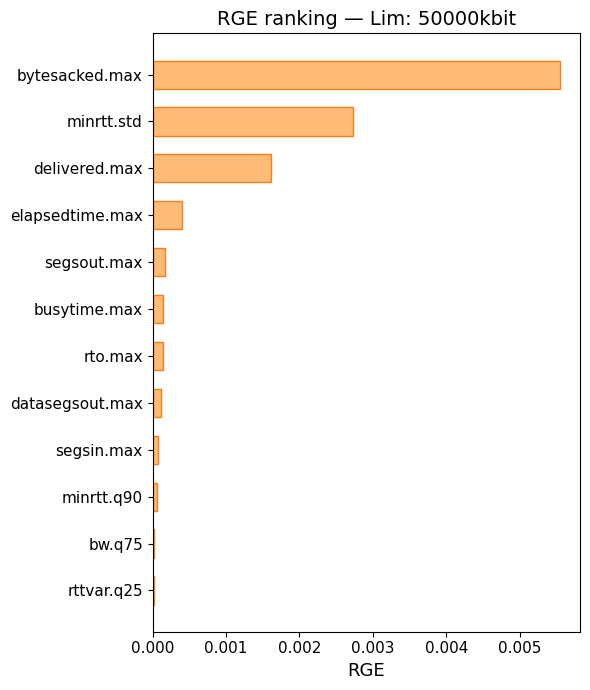

In [24]:
from src.plot_functions import plot_rge_ranking
plot_rge_ranking(safeai_results["rge"], lim)

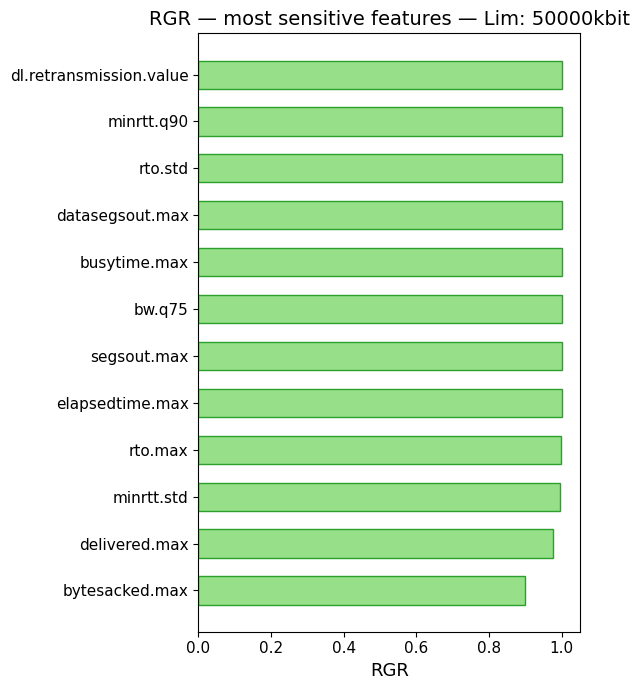

In [28]:
from src.plot_functions import plot_rgr_ranking
plot_rgr_ranking(safeai_results["rgr"], lim)

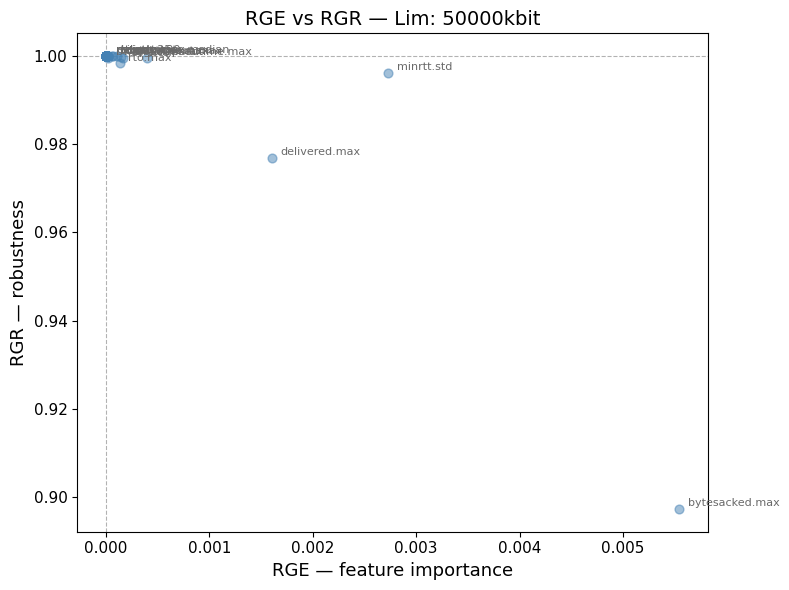

In [30]:
from src.plot_functions import plot_rge_vs_rgr
plot_rge_vs_rgr(safeai_results["rge"], safeai_results["rgr"], lim)

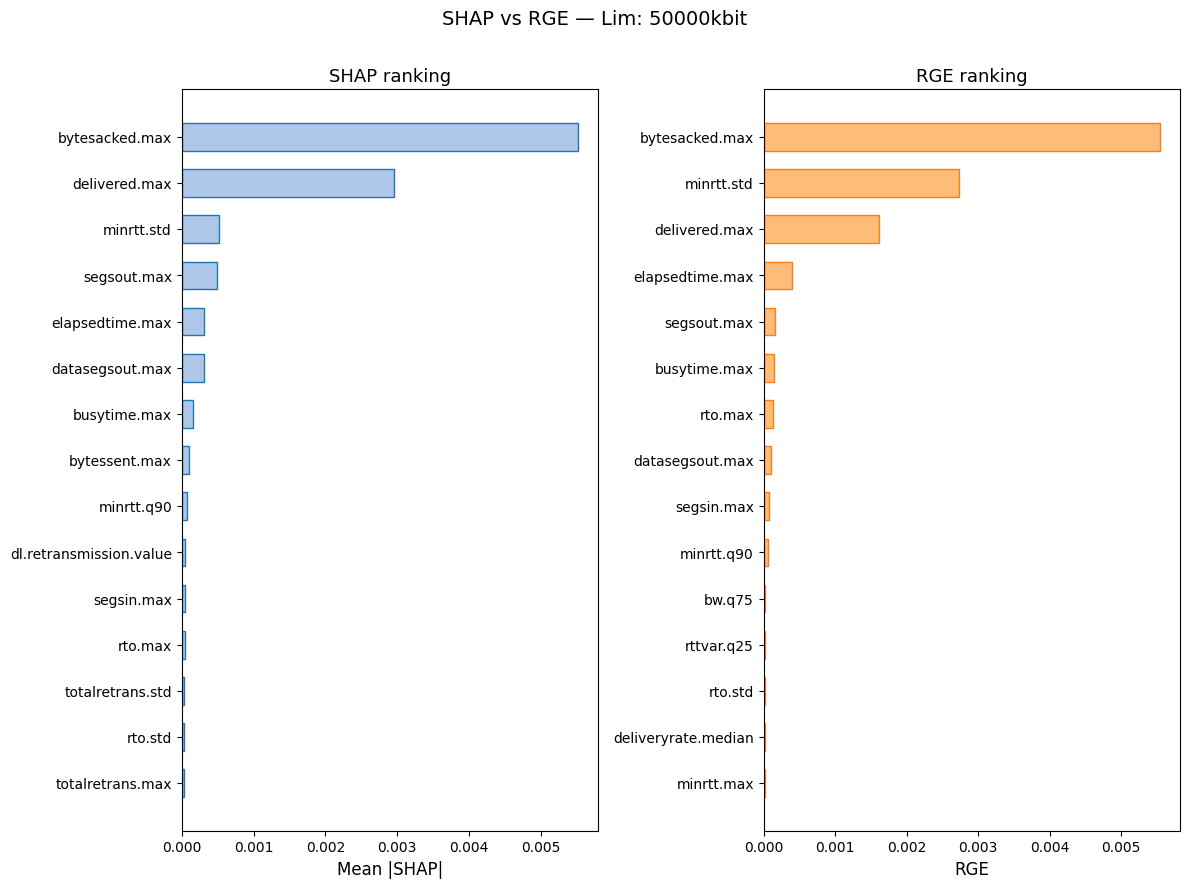

In [33]:
from src.plot_functions import plot_shap_vs_rge
plot_shap_vs_rge(results[lim]["shap_ranking"], safeai_results["rge"], lim)

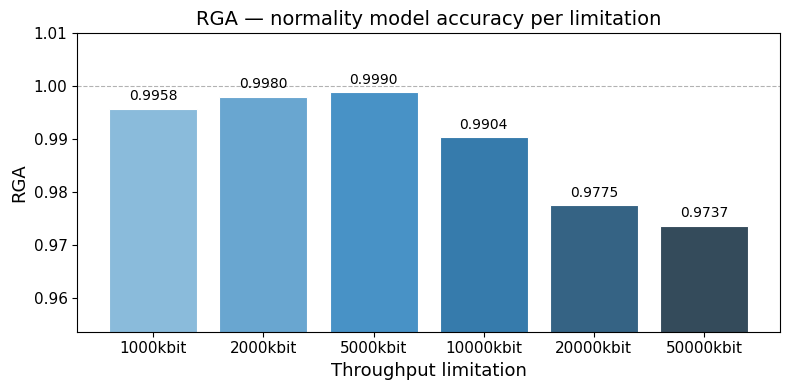

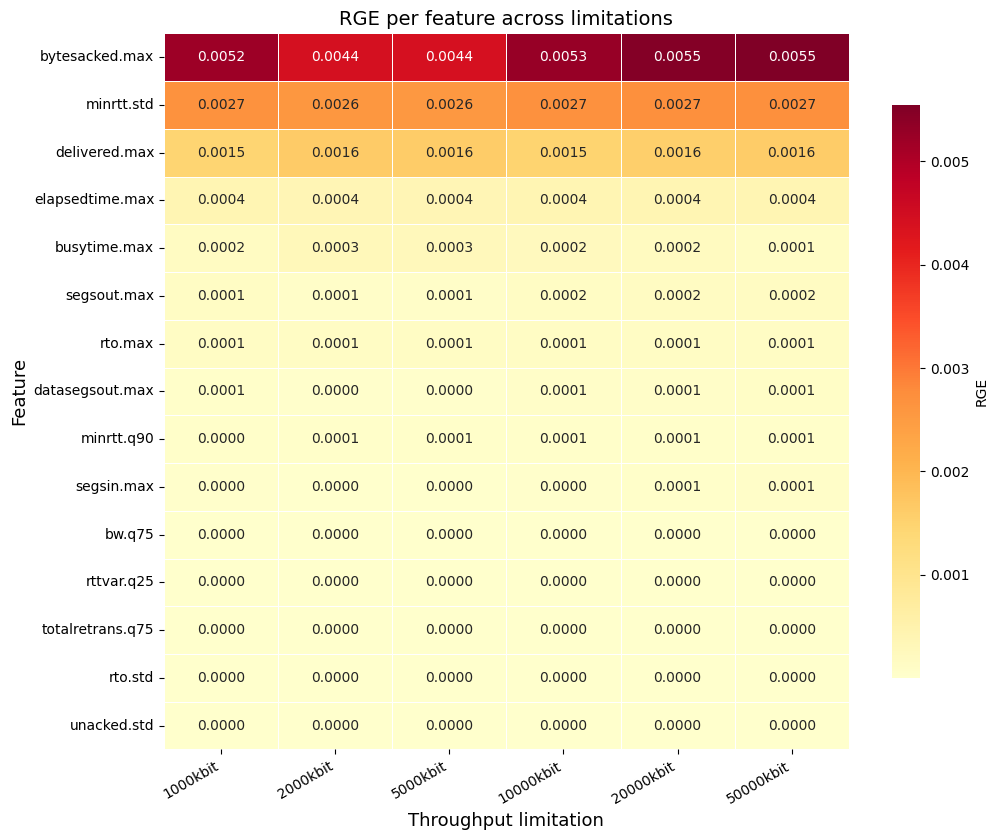

In [35]:
from src.plot_functions import plot_rga_by_limitation, plot_rge_heatmap

# RGA summary
rga_scores = {lim: results[lim]["safeai"]["rga"] for lim in THROUGHPUT_LIMS}
plot_rga_by_limitation(rga_scores)

# RGE heatmap cross-limitation
plot_rge_heatmap(results, THROUGHPUT_LIMS, top_n=15)

## 7. ROAD feature ranking

For each feature, fit 1-D GMMs with increasing number of clusters and compute
the Jaccard index between each cluster and the anomaly mask.
The ROAD index is the maximum Jaccard score — higher means stronger association with anomalies.

In [14]:
for lim in THROUGHPUT_LIMS:
    r     = results[lim]
    data1 = r["X_lim"].drop(columns=[TARGET])

    models, cls_mat = cluster_anomaly_support_optimal(
        data1, r["anomalies"], list(data1.columns), []
    )

    results[lim].update({
        "road_models": models,
        "cls_mat":     cls_mat,
        "data1":       data1,
    })

    print(f"\n=== {lim} ===")
    print(models.to_string(index=False))

    plot_road_ranking(
        models["road_index"].values,
        models["Attribute"].values,
    )


=== 1000kbit ===
        Attribute  road_index  Class_1  Class_2
           counts         1.0 0.951867 0.048133
bytesreceived.q75         1.0 0.951867 0.048133
bytesreceived.q90         1.0 0.951867 0.048133
      segsout.max         1.0 0.951867 0.048133

=== 2000kbit ===
   Attribute  road_index  Class_1  Class_2
      counts         1.0  0.95251  0.04749
 segsout.max         1.0  0.95251  0.04749
segsout.mean         1.0  0.95251  0.04749
 segsout.std         1.0  0.95251  0.04749

=== 5000kbit ===
       Attribute  road_index  Class_1  Class_2
      sndwnd.q90         1.0 0.952295 0.047705
      segsin.q75         1.0 0.952295 0.047705
      segsin.q90         1.0 0.952295 0.047705
notsentbytes.max         1.0 0.952295 0.047705

=== 10000kbit ===
          Attribute  road_index  Class_1  Class_2
         sndwnd.q90         1.0 0.951439 0.048561
  notsentbytes.mean         1.0 0.951439 0.048561
notsentbytes.median         1.0 0.951439 0.048561
   notsentbytes.q10         1.0 0.951

## 8. Decision tree

Build an interpretable CART classifier to describe the feature intervals
associated with detected anomalies. The tree is pruned via cost-complexity
pruning with cross-validation to avoid overfitting.

In [15]:
for lim in THROUGHPUT_LIMS:
    r      = results[lim]
    models = r["road_models"]
    cls_mat = r["cls_mat"]
    data1   = r["data1"]
    anomalies = r["anomalies"]

    attributes, att_ind = np.unique(models["Attribute"].values, return_index=True)
    cls_mat_unique      = cls_mat[:, att_ind]

    separator = ";"
    problem   = np.empty(cls_mat_unique.shape[0], dtype=object)
    for ii in range(cls_mat_unique.shape[0]):
        strings = []
        for jj in range(cls_mat_unique.shape[1]):
            if cls_mat_unique[ii, jj] == 1 and anomalies.iloc[ii]:
                strings.append(f"T{jj+1}P")
            elif cls_mat_unique[ii, jj] == 2 or (cls_mat_unique[ii, jj] == 1 and not anomalies.iloc[ii]):
                strings.append(f"T{jj+1}N")
        problem[ii] = separator.join(strings)

    X_dt            = data1.copy()
    X_dt["Problem"] = problem
    X_dt.loc[~X_dt["Problem"].str.contains("P"), "Problem"] = "Compliant"
    y_dt            = X_dt.pop("Problem")

    m3 = DTClassifier(DT_MAX_DEPTH, DT_MIN_SAMPLES, DT_CROSS_VAL)
    m3.fit(X_dt, y_dt)

    dot_data = tree.export_graphviz(
        m3.model,
        feature_names=np.array(X_dt.columns),
        class_names=m3.model.classes_,
        filled=True,
        rounded=True,
        out_file=None,
        precision=6,
        special_characters=True,
    )
    graph        = graphviz.Source(dot_data)
    graph.format = "png"
    output_path  = graph.render(filename=str(TREE_DIR / f"lim_{lim}"))
    print(f"{lim:12s} — decision tree saved to {output_path}")

Model training finished in 2.8759 seconds
1000kbit     — decision tree saved to /Users/gixs/Project/SafeAI/NetPredict-Public/SafeAI/data_lab/decision_trees/lim_1000kbit.png
Model training finished in 1.2745 seconds
2000kbit     — decision tree saved to /Users/gixs/Project/SafeAI/NetPredict-Public/SafeAI/data_lab/decision_trees/lim_2000kbit.png
Model training finished in 0.5377 seconds
5000kbit     — decision tree saved to /Users/gixs/Project/SafeAI/NetPredict-Public/SafeAI/data_lab/decision_trees/lim_5000kbit.png
Model training finished in 0.5057 seconds
10000kbit    — decision tree saved to /Users/gixs/Project/SafeAI/NetPredict-Public/SafeAI/data_lab/decision_trees/lim_10000kbit.png
Model training finished in 0.5279 seconds
20000kbit    — decision tree saved to /Users/gixs/Project/SafeAI/NetPredict-Public/SafeAI/data_lab/decision_trees/lim_20000kbit.png
Model training finished in 0.4985 seconds
50000kbit    — decision tree saved to /Users/gixs/Project/SafeAI/NetPredict-Public/SafeAI/d

In [ ]:
import pickle

from src.config import OUT_DATASETS

with open(OUT_DATASETS / "results.pkl", "wb") as f:
    # salva solo quello che serve per il report
    # esclude oggetti pesanti come i modelli XGBoost
    report_data = {
        lim: {
            "comparison":    r["comparison"],
            "shap_ranking":  r["shap_ranking"],
            "anomalies":     r["anomalies"],
            "outliers_mad":  r["outliers_mad"],
            "outliers_real": r["outliers_real"],
            "safeai":        r["safeai"],
            "road_models":   r["road_models"],
        }
        for lim, r in results.items()
    }
    pickle.dump(report_data, f)
print("Results saved to output_datasets/results.pkl")

Results saved to output_datasets/results.pkl
